# Tuesday - 04/21/2026

## Part 1: Coding Challenge (40 min)

Build an image classifier on MNIST (handwritten digits 0-9) using a CNN from scratch.
Requirements:

- Build your own CNN (no transfer learning)
- 2-3 convolutional blocks
- Proper train/val/test split (use MNIST's built-in train/test, split train into train/val)
- Batch normalization after conv layers
- Training loop with validation
- Early stopping
- Report final test accuracy

Twist: MNIST images are 28×28 grayscale (1 channel), not 32×32 RGB like CIFAR. Adjust your architecture accordingly.
From memory! See how much you've locked in.

In [1]:
import torch
import torchvision

In [2]:
#packages
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn

# Datasets and Dataloaders

In [3]:
#TRANSFORMS
train_transforms = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)), #MNIST normalization. 1 channel
])

test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)), #MNIST normalization. 1 channel
])  

#DATASET
full_dataset = datasets.MNIST(
    root="./data_mnist",
    train=True,
    transform=test_transforms, #need to manually make train later, **
    download=False #change to false after it comes through
)

num_classes=len(full_dataset.classes)

#val split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset,[train_size,val_size])
train_dataset.dataset.transform = train_transforms #manually made train **

test_dataset = datasets.MNIST(
    root="./data_mnist",
    train=False,
    transform=test_transforms, #need to manually make train later, **
    download=False #change to false after it comes through
)

#DATALOADERS
batch_size=32
train_dataloader = DataLoader(train_dataset,batch_size,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size,shuffle=False)

# CNN From Scratch

In [4]:
class CNN_MNIST(nn.Module):

    def __init__(self,num_classes):
        super().__init__()
        self.num_classes = num_classes

        #Conv blocks
        self.conv = nn.Sequential(
            #1.
            nn.Conv2d(1,32,(3,3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),
            #2. 
            nn.Conv2d(32,64,(3,3)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),
            #.3 
            nn.Conv2d(64,32,(3,3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,2))
        )

        #in_features computaton 
        with torch.no_grad():
            x = torch.randn(1,1,28,28) #MNIST single input SHAPE
            x = self.conv(x)
            in_features = x.view(-1).shape[0]

        self.linear_stack = nn.Sequential(
            nn.Linear(in_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU()
        )

        self.fc = nn.Linear(32,num_classes)

    def forward(self,x):
        x = self.conv(x)
        x = torch.flatten(x,1)
        x = self.linear_stack(x)
        logits = self.fc(x)
        return logits

# Optimizer, Loss, LR Scheduling

In [5]:
epochs = 100
model = CNN_MNIST(10)
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
#New LR Scheduler. It smoothly decreases like a cosine curve. Will go no lower than 1e-6. This is not a patience-based lr scheduler
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs,eta_min=1e-6)
loss_fn = nn.CrossEntropyLoss()

In [6]:
class EarlyStopping:

    def __init__(self,patience=5,min_delta=0):
        self.patience = patience #how many epochs to wait after last improvement 
        self.min_delta = min_delta #minimum change to qualify as improvement
        self.counter = 0 
        self.best_loss = None
        self.early_stop = False

    def __call__(self,val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter+=1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                # kill it 
                self.early_stop=True
        else:
            #here is the reset. 
            self.best_loss = val_loss
            self.counter = 0 

# Model Training

In [7]:
train_losses = []
val_losses = []

In [8]:
def train_loop(model,optimizer,loss_fn,lr_scheduler,early_stopping,train_dataloader,val_dataloader,train_losses,val_losses,epochs=100):

    best_loss = float("inf")

    for epoch in range(epochs):

        #TRAINING
        model.train()
        train_loss = 0.0

        for X,y in train_dataloader:
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_fn(y_pred,y)
            loss.backward()
            optimizer.step()

            train_loss+=loss.item()

        avg_train_loss = train_loss/len(train_dataloader)
        train_losses.append(avg_train_loss)
        print(f"Epoch {epoch+1} | Loss: {avg_train_loss}")

        #VAL
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X,y in val_dataloader:
                y_pred = model(X)
                loss = loss_fn(y_pred,y)

                val_loss+=loss.item()
        
        avg_val_loss = val_loss/len(val_dataloader)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} | Loss: {avg_val_loss}")

        #SAVE BEST MODEL
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(),"best_mnist_cnn.pth")

        #LR SCHEDULER
        lr_scheduler.step()

        #EARLY STOPPING
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("EARLY STOPPING TRIGGERED")
            break

    print("TRAINING KATHAM")

In [9]:
early_stopping = EarlyStopping(5,0)
train_loop(model,optimizer,loss_fn,lr_scheduler,early_stopping,train_dataloader,val_dataloader,train_losses,val_losses,epochs=100)

Epoch 1 | Loss: 0.24002506582190594
Epoch 1 | Loss: 0.10468353670897583
Epoch 2 | Loss: 0.09137549053660284
Epoch 2 | Loss: 0.08778173148756226
Epoch 3 | Loss: 0.07397109237266704
Epoch 3 | Loss: 0.062219787319501244
Epoch 4 | Loss: 0.06292764210623379
Epoch 4 | Loss: 0.056326808697544035
Epoch 5 | Loss: 0.0558368611583525
Epoch 5 | Loss: 0.07082967597603176
EarlyStopping counter: 1/5
Epoch 6 | Loss: 0.05194382691627834
Epoch 6 | Loss: 0.05507820707730328
Epoch 7 | Loss: 0.04787556141349099
Epoch 7 | Loss: 0.056290214594764014
EarlyStopping counter: 1/5
Epoch 8 | Loss: 0.04189072166525875
Epoch 8 | Loss: 0.05425467048725113
Epoch 9 | Loss: 0.04006562303290896
Epoch 9 | Loss: 0.05962527726443174
EarlyStopping counter: 1/5
Epoch 10 | Loss: 0.03595730629341173
Epoch 10 | Loss: 0.05832595340441912
EarlyStopping counter: 2/5
Epoch 11 | Loss: 0.034896942477222186
Epoch 11 | Loss: 0.057314872725711515
EarlyStopping counter: 3/5
Epoch 12 | Loss: 0.03209734740697119
Epoch 12 | Loss: 0.052613807

In [10]:
import matplotlib.pyplot as plt

def plot_results(train_losses,val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

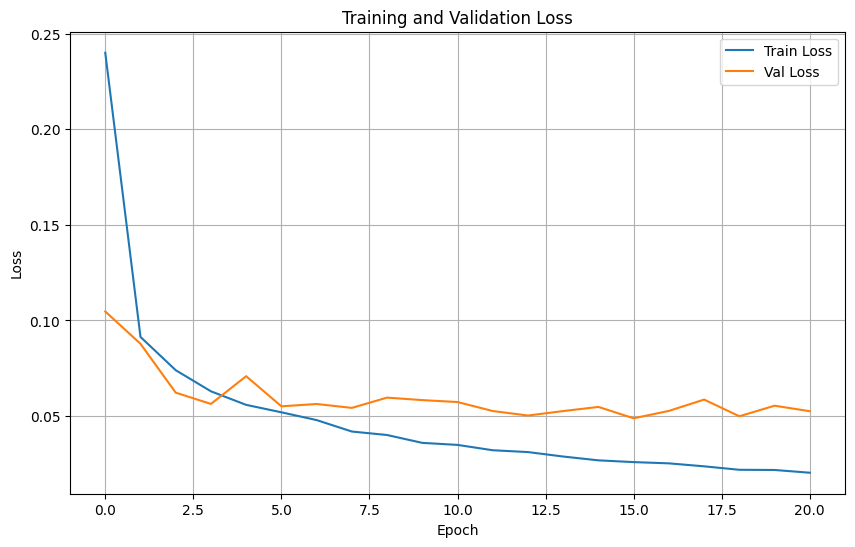

In [11]:
plot_results(train_losses,val_losses)

In [12]:
print(f"So far only trained for {len(train_losses)} epochs")

So far only trained for 21 epochs


Let's train some more

In [13]:
early_stopping = EarlyStopping(10,0.001)
train_loop(model,optimizer,loss_fn,lr_scheduler,early_stopping,train_dataloader,val_dataloader,train_losses,val_losses,epochs=100)

Epoch 1 | Loss: 0.020548469674347872
Epoch 1 | Loss: 0.05090730685428328
Epoch 2 | Loss: 0.019891669356854134
Epoch 2 | Loss: 0.051648366569367984
EarlyStopping counter: 1/10
Epoch 3 | Loss: 0.017899486126717722
Epoch 3 | Loss: 0.04663115466165618
Epoch 4 | Loss: 0.018981967585516336
Epoch 4 | Loss: 0.0531529653716522
EarlyStopping counter: 1/10
Epoch 5 | Loss: 0.016835927024115033
Epoch 5 | Loss: 0.05178996711545915
EarlyStopping counter: 2/10
Epoch 6 | Loss: 0.017848277578216463
Epoch 6 | Loss: 0.051297405229538226
EarlyStopping counter: 3/10
Epoch 7 | Loss: 0.016344411254906845
Epoch 7 | Loss: 0.05161884833248648
EarlyStopping counter: 4/10
Epoch 8 | Loss: 0.015274242736672628
Epoch 8 | Loss: 0.04850900587889676
EarlyStopping counter: 5/10
Epoch 9 | Loss: 0.014991294744609453
Epoch 9 | Loss: 0.06587743154342994
EarlyStopping counter: 6/10
Epoch 10 | Loss: 0.013502249505778005
Epoch 10 | Loss: 0.055821704148240316
EarlyStopping counter: 7/10
Epoch 11 | Loss: 0.01401900219606235
Epoch

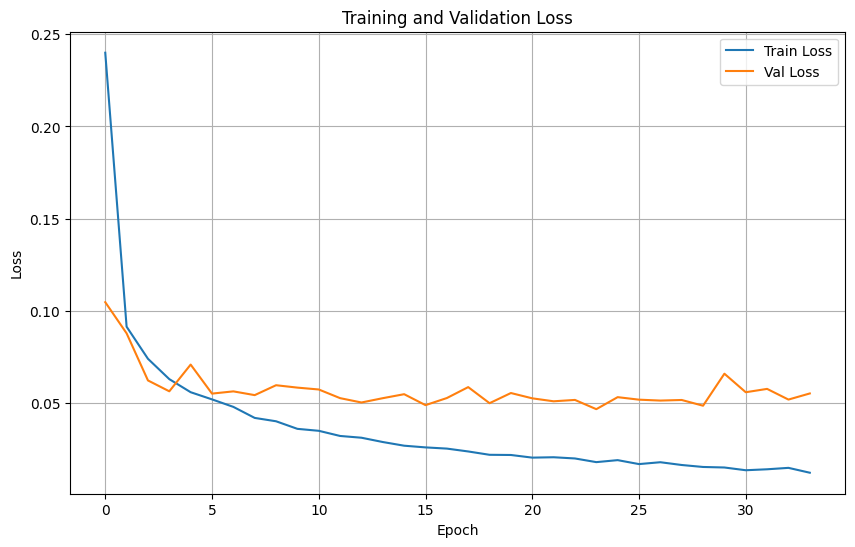

In [14]:
plot_results(train_losses,val_losses)

# Deploy Model

In [15]:
#load best
model.load_state_dict(torch.load("best_mnist_cnn.pth"))

/var/folders/j6/nvqwll1n4rxg2f3xyd5_41lc0000gn/T/ipykernel_4146/2859076775.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mnist_c

<All keys matched successfully>

In [16]:
def test_loop(model,loss_fn,test_dataloader):

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X,y in test_dataloader:
            y_pred = model(X)
            loss = loss_fn(y_pred,y)

            test_loss+=loss.item()

            _,predicted = torch.max(y_pred,1)
            total+=y.size(0)
            correct+=(predicted==y).sum().item()

    test_accuracy = correct/total
    avg_test_loss = test_loss/len(test_dataloader)

    return avg_test_loss,test_accuracy

In [17]:
test_loss, test_accuracy = test_loop(model,loss_fn,test_dataloader)
print(test_loss,test_accuracy)

0.04707231292879148 0.9893


# Part 2: Concept Questions (20 min)

1. What's the difference between nn.BatchNorm2d and nn.Dropout? When do you use each?

I know that nn.Dropout turns off random neurons to prevent overfitting. I think of it as giving the model the ability to learn in a more distracted or less ideal environment. I don't know the purpose of it, but nn.BatchNorm2d applies batch normalization. That normalizes activations and reduces internal covariate shift. 

2. Your model has these layers:

- nn.Conv2d(64, 128, 3)
- nn.MaxPool2d(2)

Input shape: (batch, 64, 14, 14). What's the output shape after both layers?

Conv2d(64, 128, 3):
64 channels --> 128 channels ; L - kernel + 1 = 14 - 3 + 1 = 12 = new L and H
after Conv2d() --> (batch, 128, 12, 12)

But now nn.MaxPool2d(2):
so each L and H /2 --> (batch, 128, 6, 6)

**Formula: output_size = (input_size - kernel_size + 1) / pool_size**

3. You're training and see:

Learning rate starts at 0.001
Scheduler reduces it to 0.0001 after epoch 10
Scheduler reduces it to 0.00001 after epoch 15

What does this tell you about your training? Is this good or bad?

It's good. It's now taking smaller and smaller steps down the valley so that it can learn better. The model is converging.

# Friday - 04/24/26 - Debugging Practice

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Transforms
train_transform = transforms.Compose([
    #bug. normalize needs to go at the end. Random flip comes before ToTensor()
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Data
train_data = datasets.CIFAR10(root='./data', train=True, transform=train_transform, download=True)
#bug. the splits need to be amounts,not proportions 
train_size = int(0.8*len(train_data))
val_size = len(train_data)-train_size
train_ds, val_ds = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True) #shuffle=True for train. bug
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

# Model
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        #bug. It's not just gonna take 64 right away. after 2 conv layers, it's 28*28
        # we should also have batchnorm and pooling layers after conv layers. 
        with torch.no_grad():
            dummy = torch.randn(1,3,32,32)
            x = self.conv1(dummy)
            x = self.conv2(x)
            in_features = x.view(-1).shape[0]
        self.fc = nn.Linear(64*28*28, num_classes)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        #bug. missing flattening layer. 
        x = torch.flatten(x,1)
        x = self.fc(x)
        # return torch.softmax(x, dim=1) bug. no need for this 
        return x

model = CNN(10)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) #bug. train all layers, not just model.fc. change to model.parameters()
loss_fn = nn.MSELoss() #bug. we are doing classification. this should be crossentropy loss

# Training
for epoch in range(5):
    for X, y in train_loader:
        #bug. no zero grad
        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

# Part 2: Concept Questions (20 min)

When would you use weight_decay=1e-4 in your optimizer? What does it actually do?

weight_decay is another form of regularization. We'd use it to prevent overfitting. Adds L2 regularization penalty

You have 50,000 training images. What's a better batch_size: 32, 64, or 128? Why?

Well it depends on our needs. 32 will go the slowest, but the model will learn the best because it will do more parameter updates per epoch. But in terms of speed, 128 is the best. 

Explain the difference between nn.ReLU() and F.relu(). Does it matter which you use?

nn.ReLU() usually goes in the constructor, while F.relu() will go in the forward. I don't think it matters. I just pick nn.ReLU()

# Saturday - 04/25/2026 - Daily Practice

Part 1: Coding Challenge (40 min)
Build a multi-class classifier on the Wine dataset from sklearn using PyTorch.
Requirements:

- Use from sklearn.datasets import load_wine
- Build a 4-layer fully connected network
- Include BatchNorm1d (for FC layers) and Dropout
- Normalize features with StandardScaler
- Train/val/test split (60/20/20)
- Track both loss and accuracy
- Use CosineAnnealingLR scheduler (practice the new one!)
- Report final test accuracy

Challenge: Wine has only ~180 samples - this tests if you can handle small datasets and avoid overfitting!
From memory! See how much you've locked in.

In [19]:
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
target_names = wine.target_names

In [20]:
print("Number of output classes:",len(target_names))
print("Number of in features",len(feature_names))

Number of output classes: 3
Number of in features 13


In [21]:
import torch
import torchvision

from torch.utils.data import DataLoader, random_split, TensorDataset
from torchvision import datasets, transforms, models
import torch.nn as nn

from torch import optim

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2)

In [23]:
def pytorch_normalize(X_tensor):
    mean = X_tensor.mean(dim=0, keepdim=True)
    std = X_tensor.std(dim=0, keepdim=True)
    return (X_tensor - mean) / std

In [24]:
#1, Convert X's to tensors
X_train = torch.tensor(X_train,dtype=torch.float32)
X_val = torch.tensor(X_val,dtype=torch.float32)
X_test = torch.tensor(X_test,dtype=torch.float32)

#2. Convert y's to tensors
y_train = torch.tensor(y_train,dtype=torch.long)
y_val = torch.tensor(y_val,dtype=torch.long)
y_test = torch.tensor(y_test,dtype=torch.long)
# regression has .reshape(-1,1) but classification will have just torch.tensor(source,dtype=torch.long) for the integer labels

#2.5 Normalize
X_train_normalized = pytorch_normalize(X_train)
X_val_normalized = pytorch_normalize(X_val)
X_test_normalized = pytorch_normalize(X_test)

#3. TensorDataset
train_dataset = TensorDataset(X_train_normalized, y_train)
val_dataset = TensorDataset(X_val_normalized, y_val)
test_dataset = TensorDataset(X_test_normalized, y_test)

#4. Dataloaders 
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

**THIS IS NOT A CNN**

In [25]:
class NOT_CNN(nn.Module):

    def __init__(self,in_feats,num_classes):
        super().__init__()
        self.in_feats = in_feats #will be 13
        self.num_classes = num_classes # will be 3
        self.fc1 = nn.Sequential(
            nn.Linear(in_feats,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5) #you were correct. dropout after relu
        )
        self.fc2 = nn.Sequential(
            nn.Linear(32,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.fc3 = nn.Sequential(
            nn.Linear(64,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        self.fc4 = nn.Sequential(
            nn.Linear(64,32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        self.output = nn.Linear(32,num_classes)

    def forward(self,x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        logits = self.output(x)
        return logits

In [26]:
model = NOT_CNN(13,3)

In [27]:
class EarlyStopping:

    def __init__(self,patience=5,min_delta=0):
        self.patience = patience #how many epochs to wait after last improvement 
        self.min_delta = min_delta #minimum change to qualify as improvement
        self.counter = 0 
        self.best_loss = None
        self.early_stop = False

    def __call__(self,val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter+=1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                # kill it 
                self.early_stop=True
        else:
            #here is the reset. 
            self.best_loss = val_loss
            self.counter = 0 

In [28]:
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100,eta_min=1e-6)

train_losses = []
val_losses = []

In [29]:
def train_loop(model,optimizer,loss_fn,lr_scheduler,train_dataloader,val_dataloader,train_losses,val_losses,early_stopping,epochs=100):

    best_loss = float("inf")

    for epoch in range(epochs):

        # == TRAINING ==

        model.train()
        train_loss = 0.0

        for X_train,y_train in train_dataloader:

            optimizer.zero_grad()
            y_pred = model(X_train)
            loss = loss_fn(y_pred,y_train)
            loss.backward()
            optimizer.step()

            train_loss+=loss.item()

        avg_train_loss = train_loss/len(train_dataloader)
        train_losses.append(avg_train_loss)
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss}")
        
        # == VAL ==

        model.eval()
        val_loss = 0.0

        with torch.no_grad():

            for X_val,y_val in val_dataloader:

                y_pred = model(X_val)
                loss = loss_fn(y_pred,y_val)
                
                val_loss += loss.item()

        avg_val_loss = val_loss/len(val_dataloader)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss}")
        
        # == LR Scheduling == 

        lr_scheduler.step()

        # == SAVE BEST MODEL == 
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(),"best_wk2_cnn.pth")

        # == EarlyStopping == 
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"early stopping triggered at epoch {epoch+1}")
            break

In [30]:
train_loop(model,optimizer,loss_fn,lr_scheduler,train_dataloader,val_dataloader,train_losses,val_losses,EarlyStopping(5,0),epochs=100)

Epoch 1 | Train Loss: 1.136898249387741
Epoch 1 | Val Loss: 1.0768917798995972
Epoch 2 | Train Loss: 1.0376544296741486
Epoch 2 | Val Loss: 1.0719307661056519
Epoch 3 | Train Loss: 0.9728519022464752
Epoch 3 | Val Loss: 1.0648053884506226
Epoch 4 | Train Loss: 1.03168123960495
Epoch 4 | Val Loss: 1.0486301183700562
Epoch 5 | Train Loss: 0.9111324995756149
Epoch 5 | Val Loss: 1.029593586921692
Epoch 6 | Train Loss: 0.925194188952446
Epoch 6 | Val Loss: 1.0031150579452515
Epoch 7 | Train Loss: 0.8523849844932556
Epoch 7 | Val Loss: 0.9699821472167969
Epoch 8 | Train Loss: 0.8150020241737366
Epoch 8 | Val Loss: 0.9377506375312805
Epoch 9 | Train Loss: 0.8241923153400421
Epoch 9 | Val Loss: 0.9027690887451172
Epoch 10 | Train Loss: 0.774242490530014
Epoch 10 | Val Loss: 0.8658071160316467
Epoch 11 | Train Loss: 0.7670898735523224
Epoch 11 | Val Loss: 0.8384750485420227
Epoch 12 | Train Loss: 0.7013550698757172
Epoch 12 | Val Loss: 0.8052769899368286
Epoch 13 | Train Loss: 0.707858875393867

In [31]:
import matplotlib.pyplot as plt
def plot_results(train_losses,val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

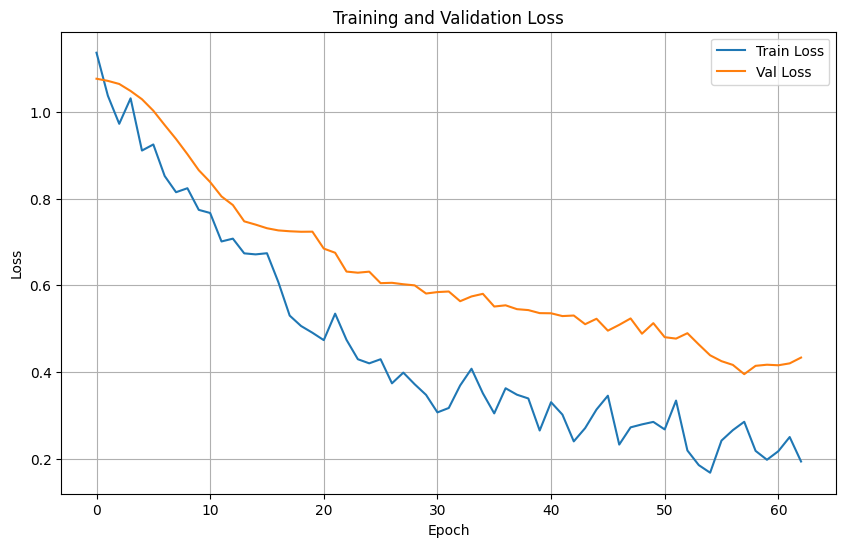

In [32]:
plot_results(train_losses,val_losses)

That's a weird looking training loss. I can't lie

In [33]:
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100,eta_min=1e-6)

In [34]:
train_loop(model,optimizer,loss_fn,lr_scheduler,train_dataloader,val_dataloader,train_losses,val_losses,EarlyStopping(10,0.01),epochs=100)

Epoch 1 | Train Loss: 0.24242312833666801
Epoch 1 | Val Loss: 0.46218279004096985
Epoch 2 | Train Loss: 0.1925799548625946
Epoch 2 | Val Loss: 0.4754273593425751
EarlyStopping counter: 1/10
Epoch 3 | Train Loss: 0.15875259414315224
Epoch 3 | Val Loss: 0.49359002709388733
EarlyStopping counter: 2/10
Epoch 4 | Train Loss: 0.2928103841841221
Epoch 4 | Val Loss: 0.49331265687942505
EarlyStopping counter: 3/10
Epoch 5 | Train Loss: 0.21405235305428505
Epoch 5 | Val Loss: 0.47341805696487427
EarlyStopping counter: 4/10
Epoch 6 | Train Loss: 0.1819218508899212
Epoch 6 | Val Loss: 0.48208847641944885
EarlyStopping counter: 5/10
Epoch 7 | Train Loss: 0.2736067995429039
Epoch 7 | Val Loss: 0.5013617873191833
EarlyStopping counter: 6/10
Epoch 8 | Train Loss: 0.23865015991032124
Epoch 8 | Val Loss: 0.529816210269928
EarlyStopping counter: 7/10
Epoch 9 | Train Loss: 0.18708139099180698
Epoch 9 | Val Loss: 0.5153419971466064
EarlyStopping counter: 8/10
Epoch 10 | Train Loss: 0.17873044684529305
Epoc

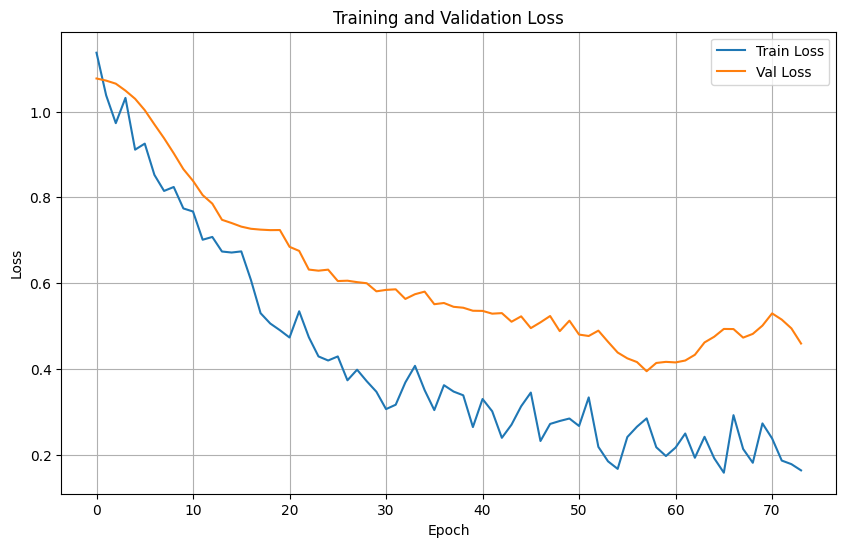

In [35]:
plot_results(train_losses,val_losses)

# Deploy Model

In [36]:
model.load_state_dict(torch.load("best_wk2_cnn.pth")) #that's funny cuz this isn't even a cnn

/var/folders/j6/nvqwll1n4rxg2f3xyd5_41lc0000gn/T/ipykernel_4146/3244098567.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_wk2_cnn

<All keys matched successfully>

In [37]:
def test_loop(model,loss_fn,test_dataloader):

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X,y in test_dataloader:
            y_pred = model(X)
            loss = loss_fn(y_pred,y)

            test_loss+=loss.item()

            _,predicted = torch.max(y_pred,1)
            correct+=(predicted==y).sum().item()
            total+=y.size(0)

    avg_test_loss = test_loss/len(test_dataloader)
    test_accuracy = correct/total

    return avg_test_loss,test_accuracy

In [38]:
test_loop(model,loss_fn,test_dataloader)

(0.20622044056653976, 0.8888888888888888)

# Part 2: Concept Questions (20 min)

1. What's the difference between nn.BatchNorm1d and nn.BatchNorm2d? When do you use each?

BatchNorm1d is for tabular 1D inputs, so basic numbers, and BatchNorm2d is for 2d tensors for when we do classification with a CNN. BatchNorm1d goes between the Linear layer and its corresponding ReLU layer. BatchNorm2d goes between the Conv2d layer and the ReLU layer, but all that before the MaxPooling2d layer. 

2. You're training and see:

Epoch 1: train_acc=40%, val_acc=38% 

Epoch 10: train_acc=65%, val_acc=62%

Epoch 20: train_acc=95%, val_acc=68%

What's happening? What would you do?

The validation accuracy is increasing but becoming flatter and flatter. I'd stop training here because it is about to overfit. I'd then use a different optimizer paired with better regularization techniques if I am going to train further.

Why do we use powers of 2 for batch_size (32, 64, 128) instead of random numbers like 50 or 100?

It's the golden rule of powers of 2. This is GPU architecture

Key things I learned today:
- AdamW is better when using weight decay. Start with 1e-4 and go higher
- torch.long for classification. No .reshape(1,-1) after
- Order for Sklearn --> DataLoader is convert to tensor with reshape, normalize, TensorDataset, DataLoader

# Sunday - 04/26

Part 1: End-to-End Mini-Project (60 min)

Build a complete image classification pipeline from data to deployment.

Task: Train a model on Fashion-MNIST (clothing items: shirts, shoes, bags, etc.)

Requirements:

1. Data: Load Fashion-MNIST, proper train/val/test splits
2. Model: CNN from scratch with BatchNorm + Dropout
3. Training: Full training loop with validation, early stopping, LR scheduling
4. Evaluation: Test accuracy + confusion matrix (which classes get confused?)
5. Save artifacts:

    - Best model checkpoint
    - Training history (loss curves) as JSON
    - Final test results as JSON

6. Inference script: Write a simple function that loads the model and predicts on new images

Deliverable: A complete, reusable project structure

### 1. Load Data

In [1]:
import torch
import torchvision

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torch.nn as nn

from torch import optim

In [2]:
#TRANSFORMS
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

#DATASETS
full_dataset = datasets.FashionMNIST(root="./data_fashion_mnist",train=True,transform=test_transform,download=False) #change to train manually, and then make download false after
sample_input, sample_label = full_dataset[0]
input_shape = sample_input.shape
num_classes = len(full_dataset.classes)

#making the val split
train_size = int(0.8*len(full_dataset))
val_size = len(full_dataset)-train_size
train_dataset, val_dataset = random_split(full_dataset,[train_size,val_size])
train_dataset.dataset.transform = train_transform

test_dataset = datasets.FashionMNIST(root="./data_fashion_mnist",train=False,transform=test_transform,download=False)

#DATALOADERS
train_dataloader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_dataloader = DataLoader(val_dataset,batch_size=32,shuffle=False)
test_dataloader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [3]:
print(num_classes)

10


We are making a CNN

In [4]:
class CNN_MNIST(nn.Module):

    def __init__(self,num_channels,num_classes):
        super().__init__()
        self.num_channels = num_channels
        self.num_classes = num_classes

        #conv block. remember that the order is conv, batchnorm2d, relu, maxpool
        self.conv = nn.Sequential(
            nn.Conv2d(self.num_channels,16,(3,3)),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),

            nn.Conv2d(16,32,(3,3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),

            nn.Conv2d(32,64,(3,3)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),
        )

        with torch.no_grad():
            dummy = torch.randn((1,1,28,28)) #(1,channels,L,W)
            x = self.conv(dummy)
            flat_size = x.view(-1).shape[0]

        self.fc = nn.Sequential(
            nn.Linear(flat_size,32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32,64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64,128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128,32),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        self.output = nn.Linear(32,10)

    def forward(self,x):
        x = self.conv(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        logits = self.output(x)
        return logits

In [5]:
class EarlyStopping:

    def __init__(self,patience=5,min_delta=0):
        self.patience = patience #how many epochs to wait after last improvement 
        self.min_delta = min_delta #minimum change to qualify as improvement
        self.counter = 0 
        self.best_loss = None
        self.early_stop = False

    def __call__(self,val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter+=1
            print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                # kill it 
                self.early_stop=True
        else:
            #here is the reset. 
            self.best_loss = val_loss
            self.counter = 0 

In [6]:
model = CNN_MNIST(1,10)
optimizer = optim.Adam(model.parameters(),lr=0.001)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=100,eta_min=1e-6)
loss_fn = nn.CrossEntropyLoss()

In [7]:
train_losses = []
val_losses = []

In [8]:
def train_loop(model,optimizer,loss_fn,lr_scheduler,train_dataloader,val_dataloader,train_losses,val_losses,early_stopping,epochs=100):

    best_loss = float("inf")

    for epoch in range(epochs):

        # == TRAINING ==

        model.train()
        train_loss = 0.0

        for X_train,y_train in train_dataloader:

            optimizer.zero_grad()
            y_pred = model(X_train)
            loss = loss_fn(y_pred,y_train)
            loss.backward()
            optimizer.step()

            train_loss+=loss.item()

        avg_train_loss = train_loss/len(train_dataloader)
        train_losses.append(avg_train_loss)
        if ((epoch+1)==1) or ((epoch+1)%10 == 0):
            print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss}")
        
        # == VAL ==

        model.eval()
        val_loss = 0.0

        with torch.no_grad():

            for X_val,y_val in val_dataloader:

                y_pred = model(X_val)
                loss = loss_fn(y_pred,y_val)
                
                val_loss += loss.item()

        avg_val_loss = val_loss/len(val_dataloader)
        val_losses.append(avg_val_loss)
        if ((epoch+1)==1) or ((epoch+1)%10 == 0):
            print(f"Epoch {epoch+1} | Val Loss: {avg_val_loss}")
        
        # == LR Scheduling == 

        lr_scheduler.step()

        # == SAVE BEST MODEL == 
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(),"./best_fmnist_.pth")

        # == EarlyStopping == 
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"early stopping triggered at epoch {epoch+1}")
            break

In [9]:
train_loop(model,optimizer,loss_fn,lr_scheduler,train_dataloader,val_dataloader,train_losses,val_losses,EarlyStopping(10,0),epochs=100)

Epoch 1 | Train Loss: 1.2229924469391504
Epoch 1 | Val Loss: 0.739583305199941
Epoch 10 | Train Loss: 0.6180686173538367
Epoch 10 | Val Loss: 0.45946897347768145
EarlyStopping counter: 1/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 1/10
Epoch 20 | Train Loss: 0.5483454569180807
Epoch 20 | Val Loss: 0.41949573000272117
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
Epoch 30 | Train Loss: 0.5188087772627672
Epoch 30 | Val Loss: 0.4161819598674774
EarlyStopping counter: 1/10
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 3/10
EarlyStopping counter: 4/10
EarlyStopping counter: 5/10
EarlyStopping counter: 6/10
EarlyStopping counter: 7/10
Epoch 40 | Train Loss: 0.4790887569387754
Epoch 40 | Val Loss: 0.4027975232601166
EarlyStopping counter: 8/10
EarlyStopping counter: 9/10
EarlyStopping counter: 10/10
ea

In [10]:
import matplotlib.pyplot as plt

def plot_results(train_losses,val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

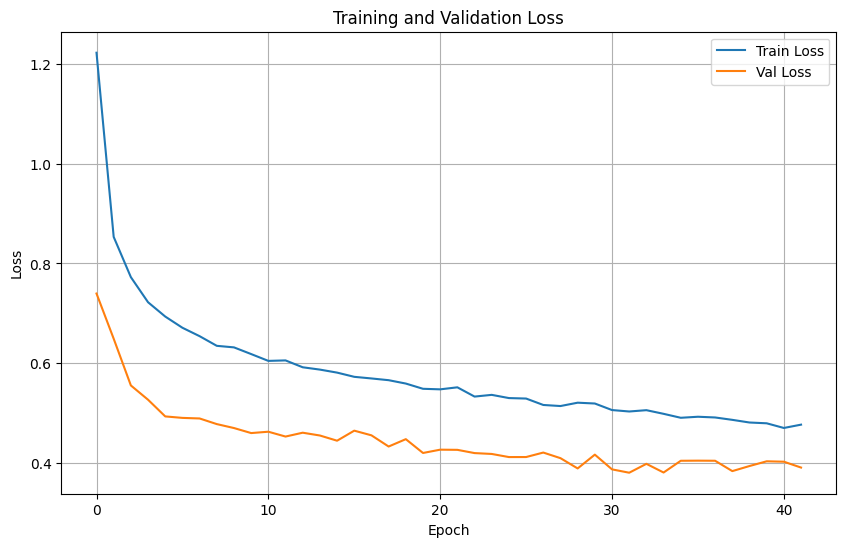

In [11]:
plot_results(train_losses,val_losses)

Let's train a bit more

In [12]:
optimizer2 = optim.AdamW(model.parameters(),lr=0.0001,weight_decay=1e-5)
lr_scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2,T_max=100,eta_min=1e-6)
loss_fn = nn.CrossEntropyLoss()

train_loop(model,optimizer2,loss_fn,lr_scheduler2,train_dataloader,val_dataloader,train_losses,val_losses,EarlyStopping(10,0.01),epochs=100)

Epoch 1 | Train Loss: 0.4552377384553353
Epoch 1 | Val Loss: 0.3809267405072848
EarlyStopping counter: 1/10
EarlyStopping counter: 2/10
EarlyStopping counter: 3/10
EarlyStopping counter: 4/10
EarlyStopping counter: 5/10
EarlyStopping counter: 6/10
EarlyStopping counter: 7/10
Epoch 10 | Train Loss: 0.42823996575673423
Epoch 10 | Val Loss: 0.3762807857592901
EarlyStopping counter: 8/10
EarlyStopping counter: 9/10
EarlyStopping counter: 10/10
early stopping triggered at epoch 12


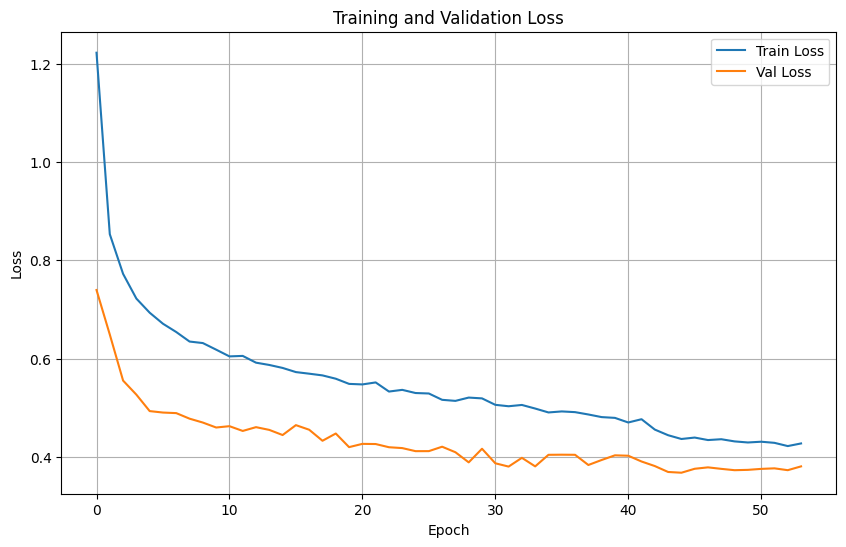

In [13]:
plot_results(train_losses,val_losses)

In [14]:
def test_loop(model,loss_fn,test_dataloader):

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X,y in test_dataloader:
            y_pred = model(X)
            loss = loss_fn(y_pred,y)

            test_loss+=loss.item()

            _,predicted = torch.max(y_pred,1)
            correct+= (predicted==y).sum().item()
            total += y.size(0)

    avg_test_loss = test_loss/len(test_dataloader)
    test_accuracy = correct/total

    return avg_test_loss,test_accuracy

In [15]:
model.load_state_dict(torch.load("./best_fmnist_.pth"))

test_loss, test_acc = test_loop(model,loss_fn,test_dataloader)

print(f"We got a test loss of {test_loss} and a test accuract of {test_acc}")

/var/folders/j6/nvqwll1n4rxg2f3xyd5_41lc0000gn/T/ipykernel_8726/1851057209.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("./best_fmnis

We got a test loss of 0.396612305658313 and a test accuract of 0.8667
